# Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
review_data = pd.read_csv('/content/IMDB Dataset.csv')


In [ ]:
review_data.shape

(50000, 2)

In [ ]:
review_data.head(20)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


# Remove Duplicate

In [ ]:
review_data.duplicated().sum()

np.int64(418)

In [ ]:
review_data.drop_duplicates(inplace=True)

# Label Counts

In [ ]:
review_data['sentiment'].value_counts()

,count
sentiment,
positive,24884
negative,24698


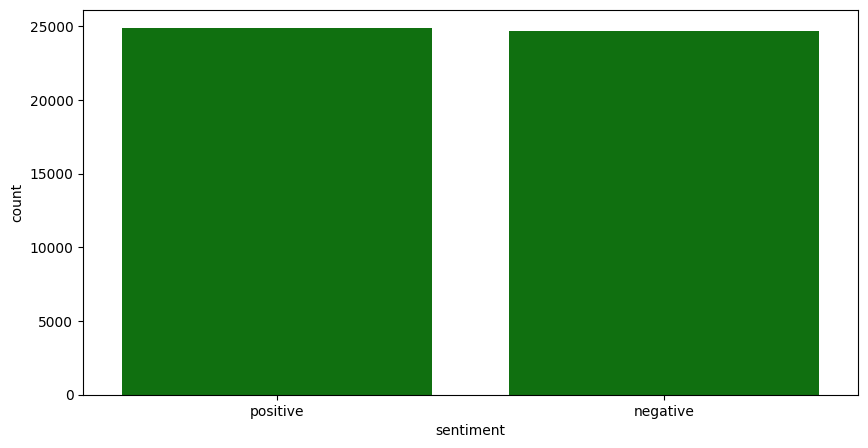

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=review_data,x='sentiment',color='green')
plt.show()

# Splitting the data into train-test

In [ ]:
x=review_data['review']
y=review_data['sentiment']

In [ ]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, stratify=y, random_state=18)

In [ ]:
print(f'examples of train: {len(train_x)}')
print(f'examples of test: {len(test_x)}')

examples of train: 39665
examples of test: 9917


In [ ]:
print(f'labels of train: {len(train_y)}')
print(f'labels of test: {len(test_y)}')

labels of train: 39665
labels of test: 9917


#  Preprocessing &  Model Pipeline

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer ,CountVectorizer
tfidf=TfidfVectorizer(ngram_range=(1,2),lowercase=True)


In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()


In [ ]:
from sklearn.pipeline import Pipeline
pipe=Pipeline([
    ('vectorizer',tfidf),
    ('model',model)
])

# Model Training  & Performance of Model

In [ ]:
pipe.fit(train_x,train_y)


Pipeline(steps=[('vectorizer', TfidfVectorizer(ngram_range=(1, 2))),
                ('model', LogisticRegression())])

In [ ]:
print(f'train score:{pipe.score(train_x,train_y)}')
print(f'test score: {pipe.score(test_x,test_y)}')

train score:0.9537627631413085
test score: 0.9006756075426036


In [ ]:
print("Performance of logistic regression model \n")
from sklearn.metrics import classification_report
y_pred=pipe.predict(test_x)
print(classification_report(test_y,y_pred))



Performance of logistic regression model 

              precision    recall  f1-score   support

    negative       0.92      0.88      0.90      4940
    positive       0.89      0.92      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



# Model Inspection

In [104]:
feature_weights = pipe.named_steps['model'].coef_[0]
feature_names = pipe.named_steps['vectorizer'].get_feature_names_out()
feature_importance = sorted(zip(feature_names, feature_weights), key=lambda x: abs(x[1]), reverse=True)
for feature, weight in feature_importance[:20]:
    print (feature, weight)

bad -10.913721368003808
great 9.696095343463602
worst -9.208042103116135
the worst -7.485705340901628
awful -7.4427954552760545
excellent 7.1403704248526605
boring -7.114711820610263
poor -6.628639321254306
waste -6.448268790367172
terrible -6.217657650735103
nothing -5.91601381643893
best 5.34099492985466
and 5.27829028408533
wonderful 5.24071062395432
no -5.233183126679797
stupid -5.231568478612386
perfect 5.146152343347895
the best 5.053387651804075
worse -5.050926891383089
horrible -4.857340296908791


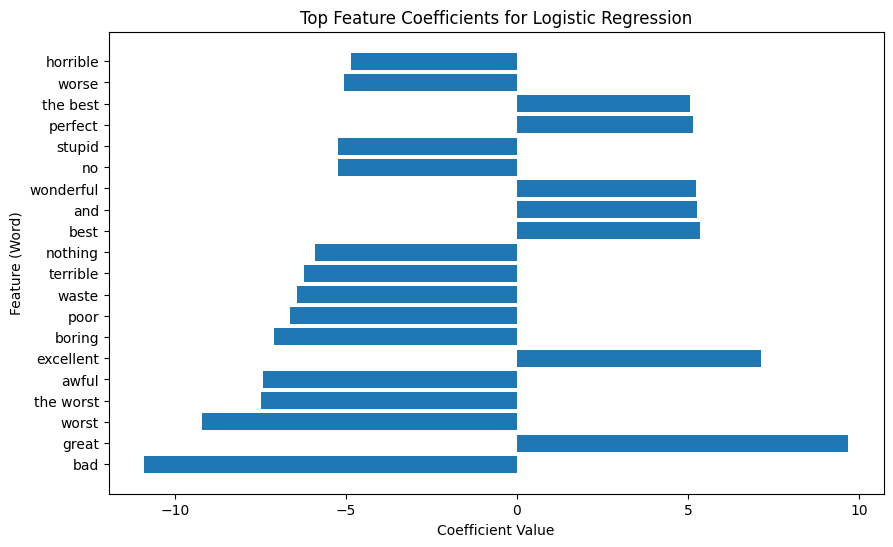

In [105]:
top_n = 20 # Visualize top 10 features
top_feature_names = [f[0] for f in feature_importance[:top_n]]
top_coefficients = [f[1] for f in feature_importance[:top_n]]

plt.figure(figsize=(10, 6))
plt.barh(top_feature_names[::-1], top_coefficients[::-1])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature (Word)")
plt.title("Top Feature Coefficients for Logistic Regression")
plt.gca().invert_yaxis() # Invert y-axis for better readability
plt.show()

# Model Selection (Hyper-parameter-tuning )

In [ ]:
from sklearn.model_selection import GridSearchCV
parms={
    'vectorizer__max_features':[50000,70000,100000],
    'model__C':[0.5,1,2],
    'model__max_iter':[1500,2000],
    'model__solver':['liblinear']
}



In [ ]:
grid=GridSearchCV(pipe,
                  parms,
                  cv=5,
                  n_jobs=-1)

In [ ]:
grid.fit(train_x,train_y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(ngram_range=(1, 2))),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.5, 1, 2],
                         'model__max_iter': [1500, 2000],
                         'model__solver': ['liblinear'],
                         'vectorizer__max_features': [50000, 70000, 100000]})

In [ ]:
best_model=grid.best_estimator_
best_parms=grid.best_params_


In [101]:
print(f'best parms :{best_parms}')

best parms :{'model__C': 2, 'model__max_iter': 1500, 'model__solver': 'liblinear', 'vectorizer__max_features': 100000}


In [98]:
from sklearn.metrics import classification_report, accuracy_score
y_pred = best_model.predict(test_x)
print(f'best model accuracy: {accuracy_score(test_y, y_pred)}')
print(f'classification report:\n{classification_report(test_y, y_pred)}')

best model accuracy: 0.9124735303015025
classification report:
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      4940
    positive       0.90      0.92      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917

